# Subset (2005-2024)

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Variables

In [1]:
cols = [
    'USTAR',  # m s-1
    'WS',  # m s-1
    'AIR_DENSITY',  # maybe kg m-3, please check 
    'H_L3.1_L3.3_CUT_NONE_QCF_gfRF',  # W m-2
    'FLAG_H_L3.1_L3.3_CUT_NONE_QCF_gfRF_ISFILLED',  # Flag, 0=measured, 1=gap-filled using random forest
    'LW_IN_T1_2_1',  # W m-2
    'LW_OUT_T1_2_1',  # W m-2
    'TA_T1_2_1', # degC
    'TS_GF1_0.04_1_gfXG', # degC
    'TS_GF1_0.15_1_gfXG', # degC
    'TS_GF1_0.4_1_gfXG', # degC
    'RH_T1_2_1',  # %
    'PREC_RAIN_TOT_GF1_0.5_1',  # mm
    'VPD_T1_2_1', # kPa
    'GPP_NT_CUT_16_gfRF',  # µmol CO2 m-2 s-1
    'GPP_NT_CUT_50_gfRF',  # µmol CO2 m-2 s-1
    'GPP_NT_CUT_84_gfRF',  # µmol CO2 m-2 s-1
    'NEE_L3.1_L3.3_CUT_16_QCF_gfRF',  # µmol CO2 m-2 s-1
    'NEE_L3.1_L3.3_CUT_50_QCF_gfRF',  # µmol CO2 m-2 s-1
    'NEE_L3.1_L3.3_CUT_84_QCF_gfRF',  # µmol CO2 m-2 s-1
    'RECO_NT_CUT_16_gfRF',  # µmol CO2 m-2 s-1
    'RECO_NT_CUT_50_gfRF',  # µmol CO2 m-2 s-1
    'RECO_NT_CUT_84_gfRF',  # µmol CO2 m-2 s-1
    'SWC_GF1_0.05_1',  # %
    'SWC_GF1_0.15_1_gfXG',  # %
    'SWC_GF1_0.75_1'  # %
]
cols

['USTAR',
 'WS',
 'AIR_DENSITY',
 'H_L3.1_L3.3_CUT_NONE_QCF_gfRF',
 'FLAG_H_L3.1_L3.3_CUT_NONE_QCF_gfRF_ISFILLED',
 'LW_IN_T1_2_1',
 'LW_OUT_T1_2_1',
 'TA_T1_2_1',
 'TS_GF1_0.04_1_gfXG',
 'TS_GF1_0.15_1_gfXG',
 'TS_GF1_0.4_1_gfXG',
 'RH_T1_2_1',
 'PREC_RAIN_TOT_GF1_0.5_1',
 'VPD_T1_2_1',
 'GPP_NT_CUT_16_gfRF',
 'GPP_NT_CUT_50_gfRF',
 'GPP_NT_CUT_84_gfRF',
 'NEE_L3.1_L3.3_CUT_16_QCF_gfRF',
 'NEE_L3.1_L3.3_CUT_50_QCF_gfRF',
 'NEE_L3.1_L3.3_CUT_84_QCF_gfRF',
 'RECO_NT_CUT_16_gfRF',
 'RECO_NT_CUT_50_gfRF',
 'RECO_NT_CUT_84_gfRF',
 'SWC_GF1_0.05_1',
 'SWC_GF1_0.15_1_gfXG',
 'SWC_GF1_0.75_1']

# Imports

In [2]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import diive as dv
from diive.core.io.files import load_parquet
from diive.core.times.times import current_datetime_str_condensed

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.87.0


# Load data

In [3]:
SOURCEDIR = r"../80_FINALIZE"
FILENAME = r"81.1_FLUXES_M15_MGMT_L4.2_NEE_GPP_RECO_LE_H_FN2O_FCH4.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)
df

Loaded .parquet file ..\80_FINALIZE\81.1_FLUXES_M15_MGMT_L4.2_NEE_GPP_RECO_LE_H_FN2O_FCH4.parquet (5.175 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-12,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-18,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-24,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-6,.SWC_GF1_0.15_1_gfXG_MEAN3H-12,.SWC_GF1_0.15_1_gfXG_MEAN3H-18,.SWC_GF1_0.15_1_gfXG_MEAN3H-24,.SWC_GF1_0.15_1_gfXG_MEAN3H-6,.TS_GF1_0.04_1_gfXG_MEAN3H-12,.TS_GF1_0.04_1_gfXG_MEAN3H-18,.TS_GF1_0.04_1_gfXG_MEAN3H-24,.TS_GF1_0.04_1_gfXG_MEAN3H-6,.TS_GF1_0.15_1_gfXG_MEAN3H-12,.TS_GF1_0.15_1_gfXG_MEAN3H-18,.TS_GF1_0.15_1_gfXG_MEAN3H-24,...,GPP_NT_CUT_50_gfRF,RECO_DT_CUT_50_gfRF,GPP_DT_CUT_50_gfRF,RECO_DT_CUT_50_gfRF_SD,GPP_DT_CUT_50_gfRF_SD,G_GF1_0.03_1,G_GF1_0.03_2,G_GF1_0.05_1,G_GF1_0.05_2,G_GF4_0.02_1,G_GF5_0.02_1,LW_OUT_T1_2_1,NETRAD_T1_2_1,PPFD_OUT_T1_2_2,SW_OUT_T1_2_1
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.918553,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.917972,0.092682,0.0,0.079688,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.163001,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.190890,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.167042,0.092295,0.0,0.079361,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,0.0,0.0,0.0,0.0,52.229004,52.226300,52.226689,52.216796,3.458828,3.150402,3.115260,3.660897,4.335667,4.347764,4.385967,...,-0.334996,1.091028,0.0,0.265808,0.0,NaN,NaN,-9.097370,-7.880106,NaN,NaN,311.167160,-5.883538,0.0,0.0
2024-12-31 22:15:00,0.0,0.0,0.0,0.0,52.227858,52.227986,52.224528,52.214211,3.522570,3.187638,3.103440,3.643396,4.338551,4.342880,4.379524,...,-0.310533,1.078751,0.0,0.264327,0.0,NaN,NaN,-9.561669,-8.172388,NaN,NaN,310.079817,-6.269816,0.0,0.0
2024-12-31 22:45:00,0.0,0.0,0.0,0.0,52.226640,52.229837,52.222456,52.209876,3.578745,3.230037,3.095339,3.624025,4.343767,4.339440,4.372636,...,-0.225651,1.079759,0.0,0.264447,0.0,NaN,NaN,-10.138718,-8.527732,NaN,NaN,309.604987,-6.934394,0.0,0.0


In [4]:
# [print(c) for c in df.columns if "SWC_" in c];
# df['VPD_T1_2_1'].describe()

# Make subset

In [5]:
df = df[cols].copy()
df

,USTAR,WS,AIR_DENSITY,H_L3.1_L3.3_CUT_NONE_QCF_gfRF,FLAG_H_L3.1_L3.3_CUT_NONE_QCF_gfRF_ISFILLED,LW_IN_T1_2_1,LW_OUT_T1_2_1,TA_T1_2_1,TS_GF1_0.04_1_gfXG,TS_GF1_0.15_1_gfXG,TS_GF1_0.4_1_gfXG,RH_T1_2_1,PREC_RAIN_TOT_GF1_0.5_1,VPD_T1_2_1,GPP_NT_CUT_16_gfRF,GPP_NT_CUT_50_gfRF,GPP_NT_CUT_84_gfRF,NEE_L3.1_L3.3_CUT_16_QCF_gfRF,NEE_L3.1_L3.3_CUT_50_QCF_gfRF,NEE_L3.1_L3.3_CUT_84_QCF_gfRF,RECO_NT_CUT_16_gfRF,RECO_NT_CUT_50_gfRF,RECO_NT_CUT_84_gfRF,SWC_GF1_0.05_1,SWC_GF1_0.15_1_gfXG,SWC_GF1_0.75_1
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:15:00,NaN,NaN,NaN,-16.302610,1,NaN,NaN,1.566667,1.014525,2.907254,4.007686,85.400000,0.0,0.099893,0.562911,0.918553,1.105825,1.237837,0.911990,0.641069,1.800748,1.830543,1.746895,NaN,47.854301,NaN
2005-01-01 00:45:00,NaN,NaN,NaN,-15.891337,1,NaN,NaN,1.533333,1.029936,2.907254,4.007686,85.700000,0.0,0.097606,0.575336,0.917972,1.101436,1.223967,0.910926,0.642671,1.799303,1.828898,1.744107,NaN,47.854301,NaN
2005-01-01 01:15:00,NaN,NaN,NaN,-14.849423,1,NaN,NaN,1.566667,1.003078,2.903765,4.077782,86.600000,0.1,0.091683,0.170341,0.163001,0.462104,1.630407,1.667542,1.284791,1.800748,1.830543,1.746895,NaN,47.627148,NaN
2005-01-01 01:45:00,NaN,NaN,NaN,-10.172901,1,NaN,NaN,1.566667,1.056877,2.903765,4.077782,89.600000,0.0,0.071157,0.277298,0.190890,0.460866,1.523451,1.639653,1.286028,1.800748,1.830543,1.746895,NaN,47.627148,NaN
2005-01-01 02:15:00,NaN,NaN,NaN,-8.028102,1,NaN,NaN,1.500000,0.963062,2.932330,3.979915,91.433333,0.1,0.058333,0.189333,0.167042,0.402870,1.608524,1.660211,1.338450,1.797856,1.827253,1.741320,NaN,48.188377,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,0.129708,1.64852,1.26052,5.006574,0,304.613900,311.167160,-1.919472,3.474346,4.437078,5.528727,99.997990,0.0,0.000011,-0.401174,-0.334996,-0.264334,1.164181,1.160720,1.210497,0.763007,0.825725,0.946163,58.725733,52.459871,45.120877
2024-12-31 22:15:00,0.143010,1.89281,1.26101,7.780867,0,303.039890,310.079817,-2.104678,3.428224,4.440415,5.521962,99.997990,0.0,0.000011,-0.369966,-0.310533,-0.261633,1.129005,1.131454,1.198036,0.759039,0.820921,0.936404,58.725118,52.633365,45.144937
2024-12-31 22:45:00,0.135574,1.72088,1.26068,6.960518,0,302.093633,309.604987,-2.089444,3.384733,4.443751,5.523991,99.997990,0.0,0.000011,-0.287601,-0.225651,-0.109761,1.046967,1.046967,1.046967,0.759366,0.821317,0.937206,58.728398,52.381308,45.152280


# Heatmap plots

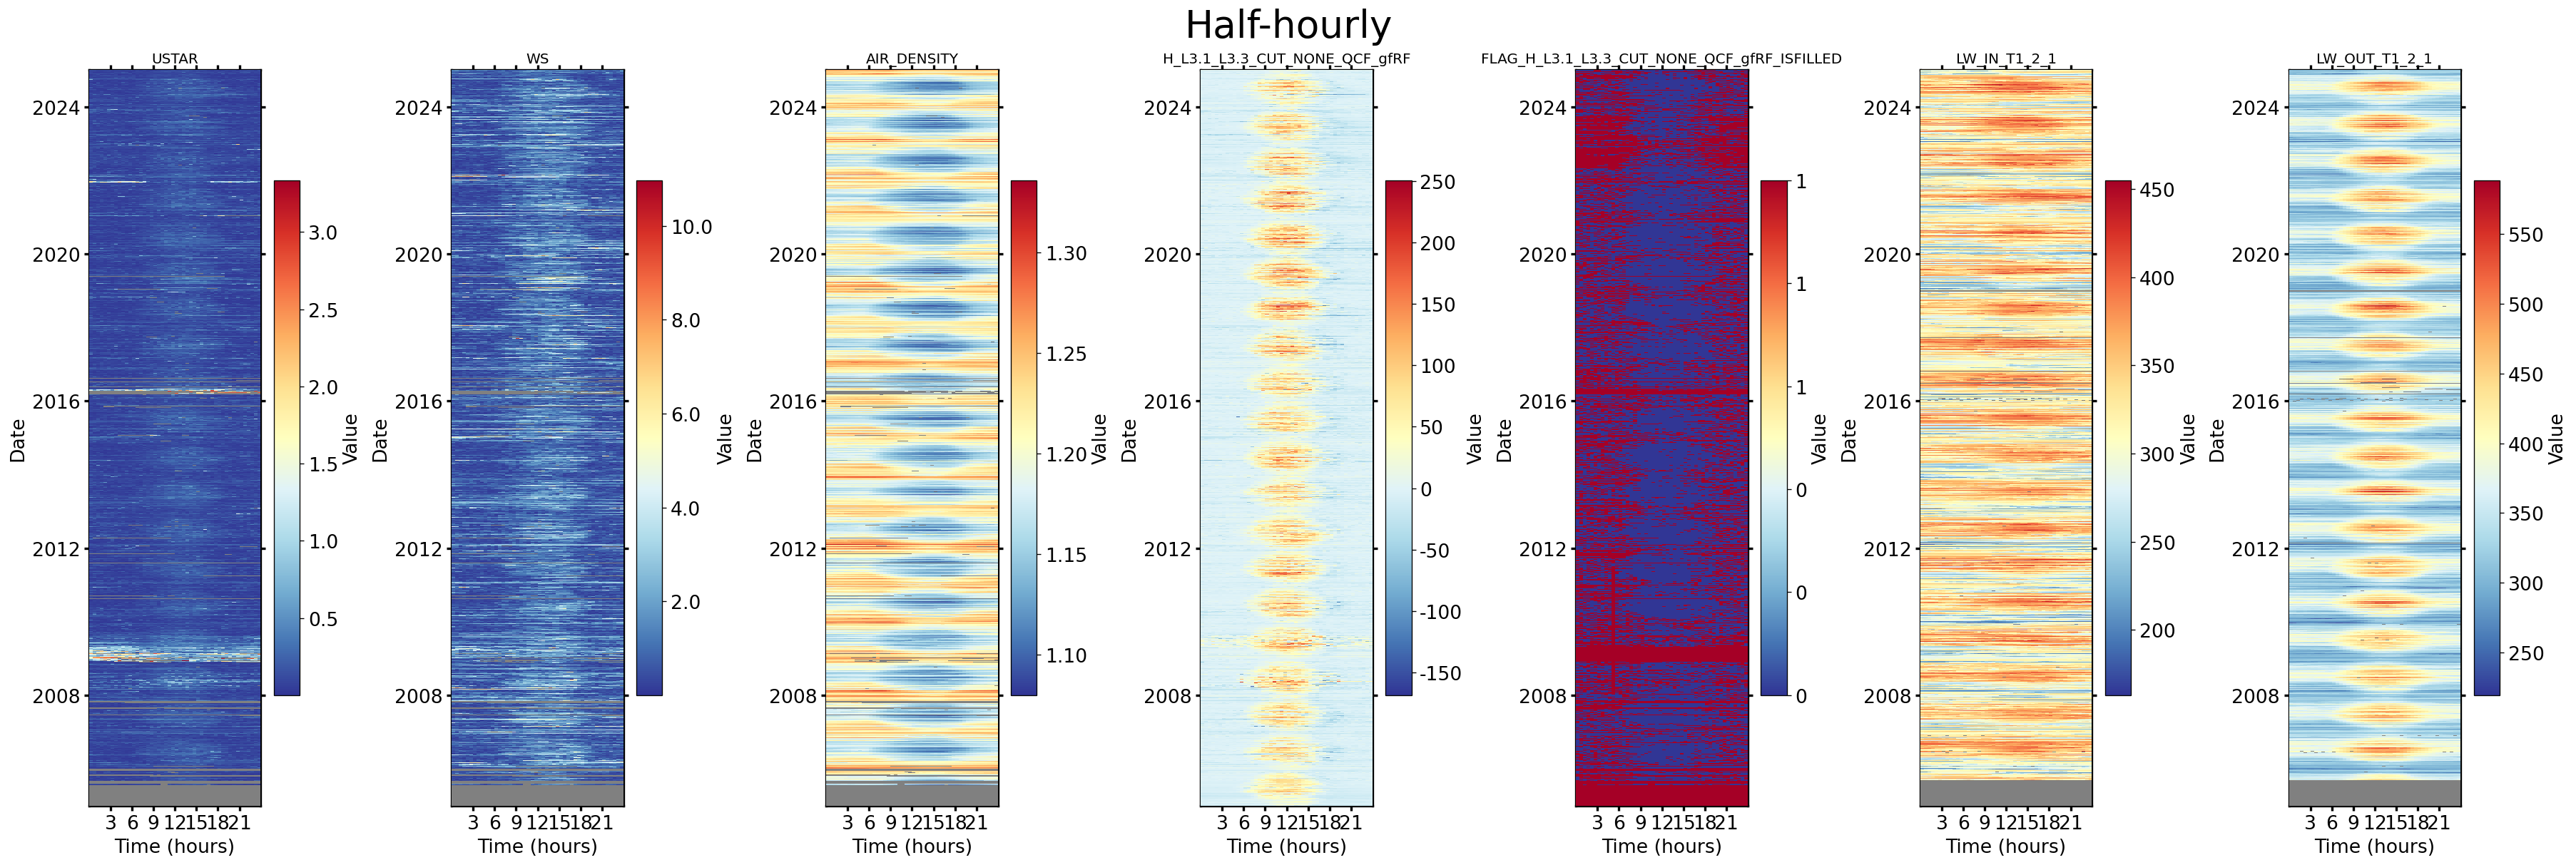

In [6]:
fig, axs = plt.subplots(ncols=7, figsize=(30, 10), dpi=120, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=32)
dv.heatmapdatetime(series=df['USTAR'], title="USTAR", ax=axs[0], cb_digits_after_comma=1).plot()
dv.heatmapdatetime(series=df['WS'], title="WS", ax=axs[1], cb_digits_after_comma=1).plot()
dv.heatmapdatetime(series=df['AIR_DENSITY'], title="AIR_DENSITY", ax=axs[2], cb_digits_after_comma=2).plot()
dv.heatmapdatetime(series=df['H_L3.1_L3.3_CUT_NONE_QCF_gfRF'], title="H_L3.1_L3.3_CUT_NONE_QCF_gfRF", ax=axs[3], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['FLAG_H_L3.1_L3.3_CUT_NONE_QCF_gfRF_ISFILLED'], title="FLAG_H_L3.1_L3.3_CUT_NONE_QCF_gfRF_ISFILLED", ax=axs[4], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['LW_IN_T1_2_1'], title="LW_IN_T1_2_1", ax=axs[5], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['LW_OUT_T1_2_1'], title="LW_OUT_T1_2_1", ax=axs[6], cb_digits_after_comma=0).plot()

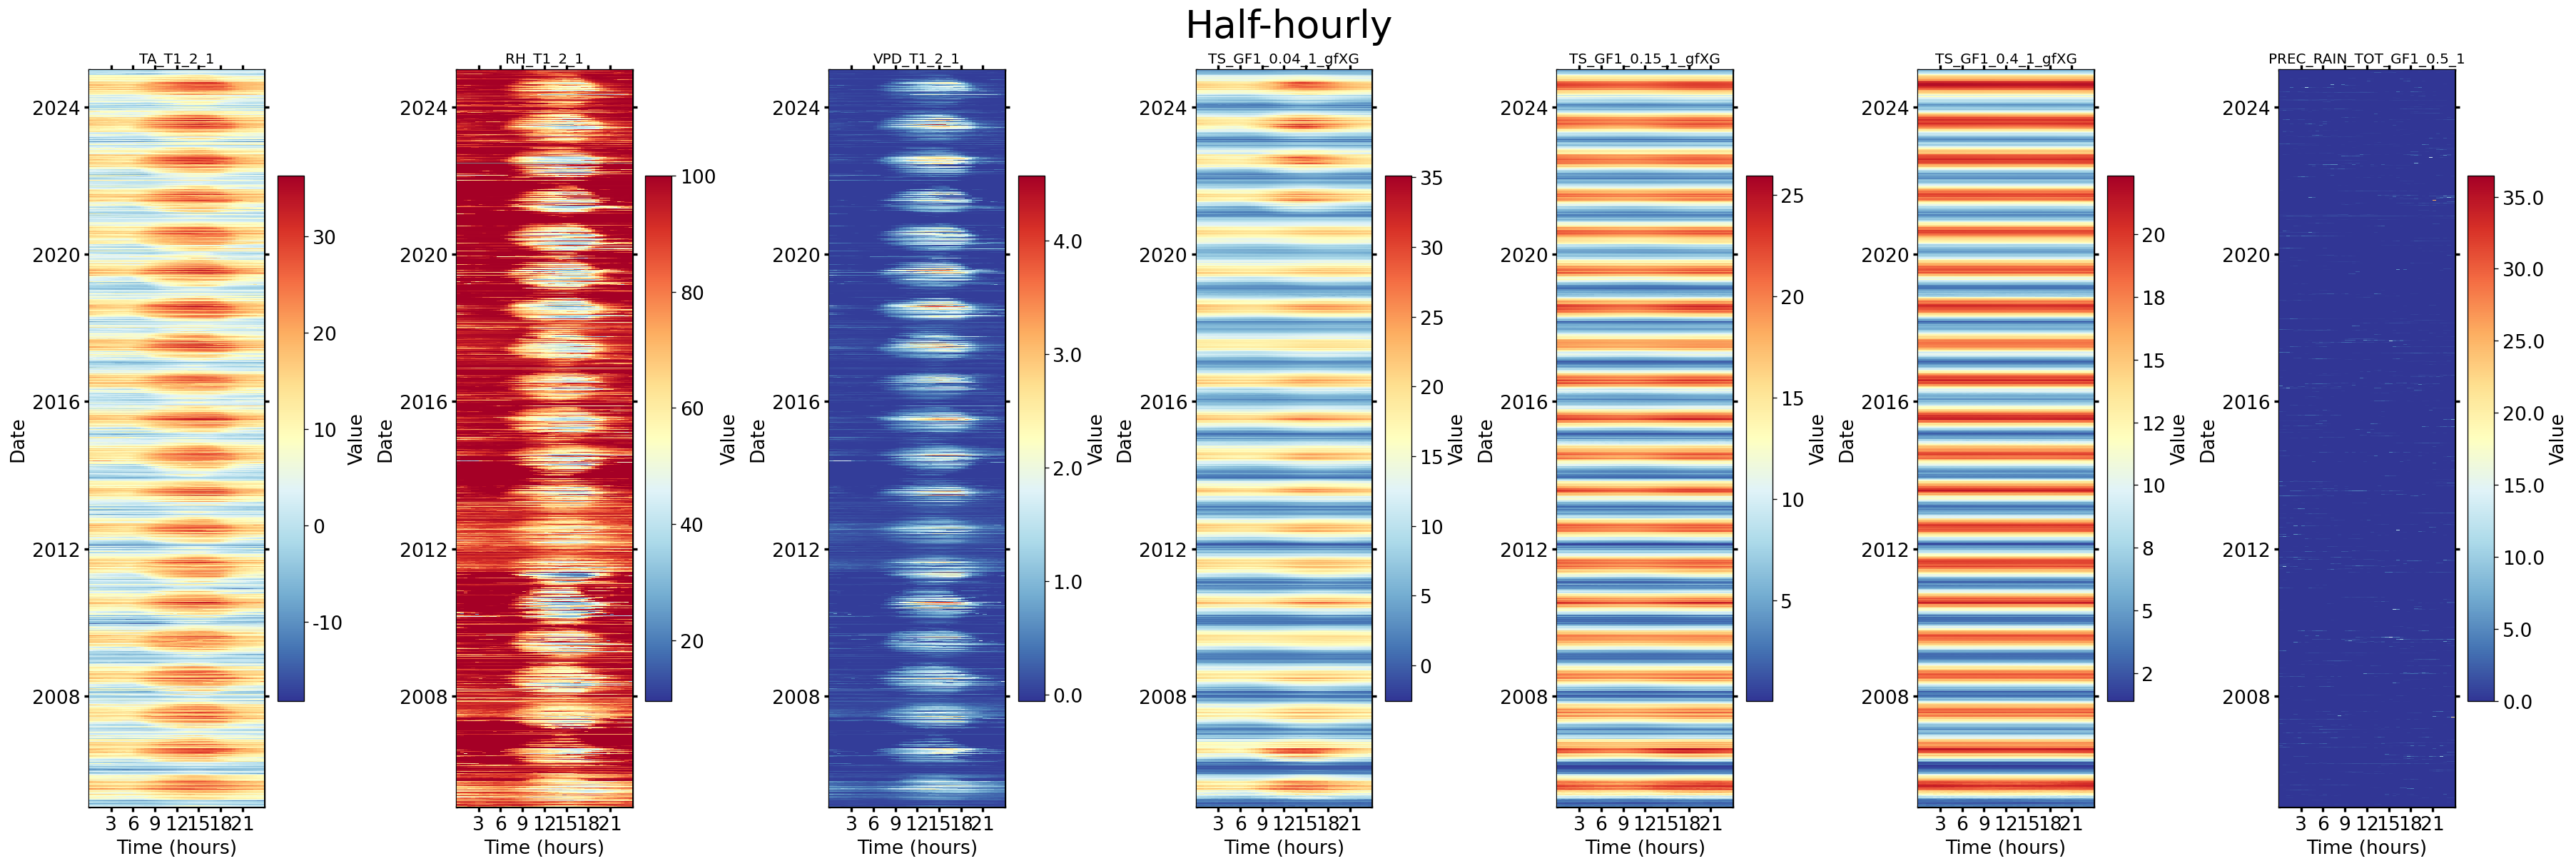

In [7]:
fig, axs = plt.subplots(ncols=7, figsize=(30, 10), dpi=120, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=32)
dv.heatmapdatetime(series=df['TA_T1_2_1'], title="TA_T1_2_1", ax=axs[0], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['RH_T1_2_1'], title="RH_T1_2_1", ax=axs[1], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['VPD_T1_2_1'], title="VPD_T1_2_1", ax=axs[2], cb_digits_after_comma=1).plot()
dv.heatmapdatetime(series=df['TS_GF1_0.04_1_gfXG'], title="TS_GF1_0.04_1_gfXG", ax=axs[3], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['TS_GF1_0.15_1_gfXG'], title="TS_GF1_0.15_1_gfXG", ax=axs[4], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['TS_GF1_0.4_1_gfXG'], title="TS_GF1_0.4_1_gfXG", ax=axs[5], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['PREC_RAIN_TOT_GF1_0.5_1'], title="PREC_RAIN_TOT_GF1_0.5_1", ax=axs[6], cb_digits_after_comma=1).plot()

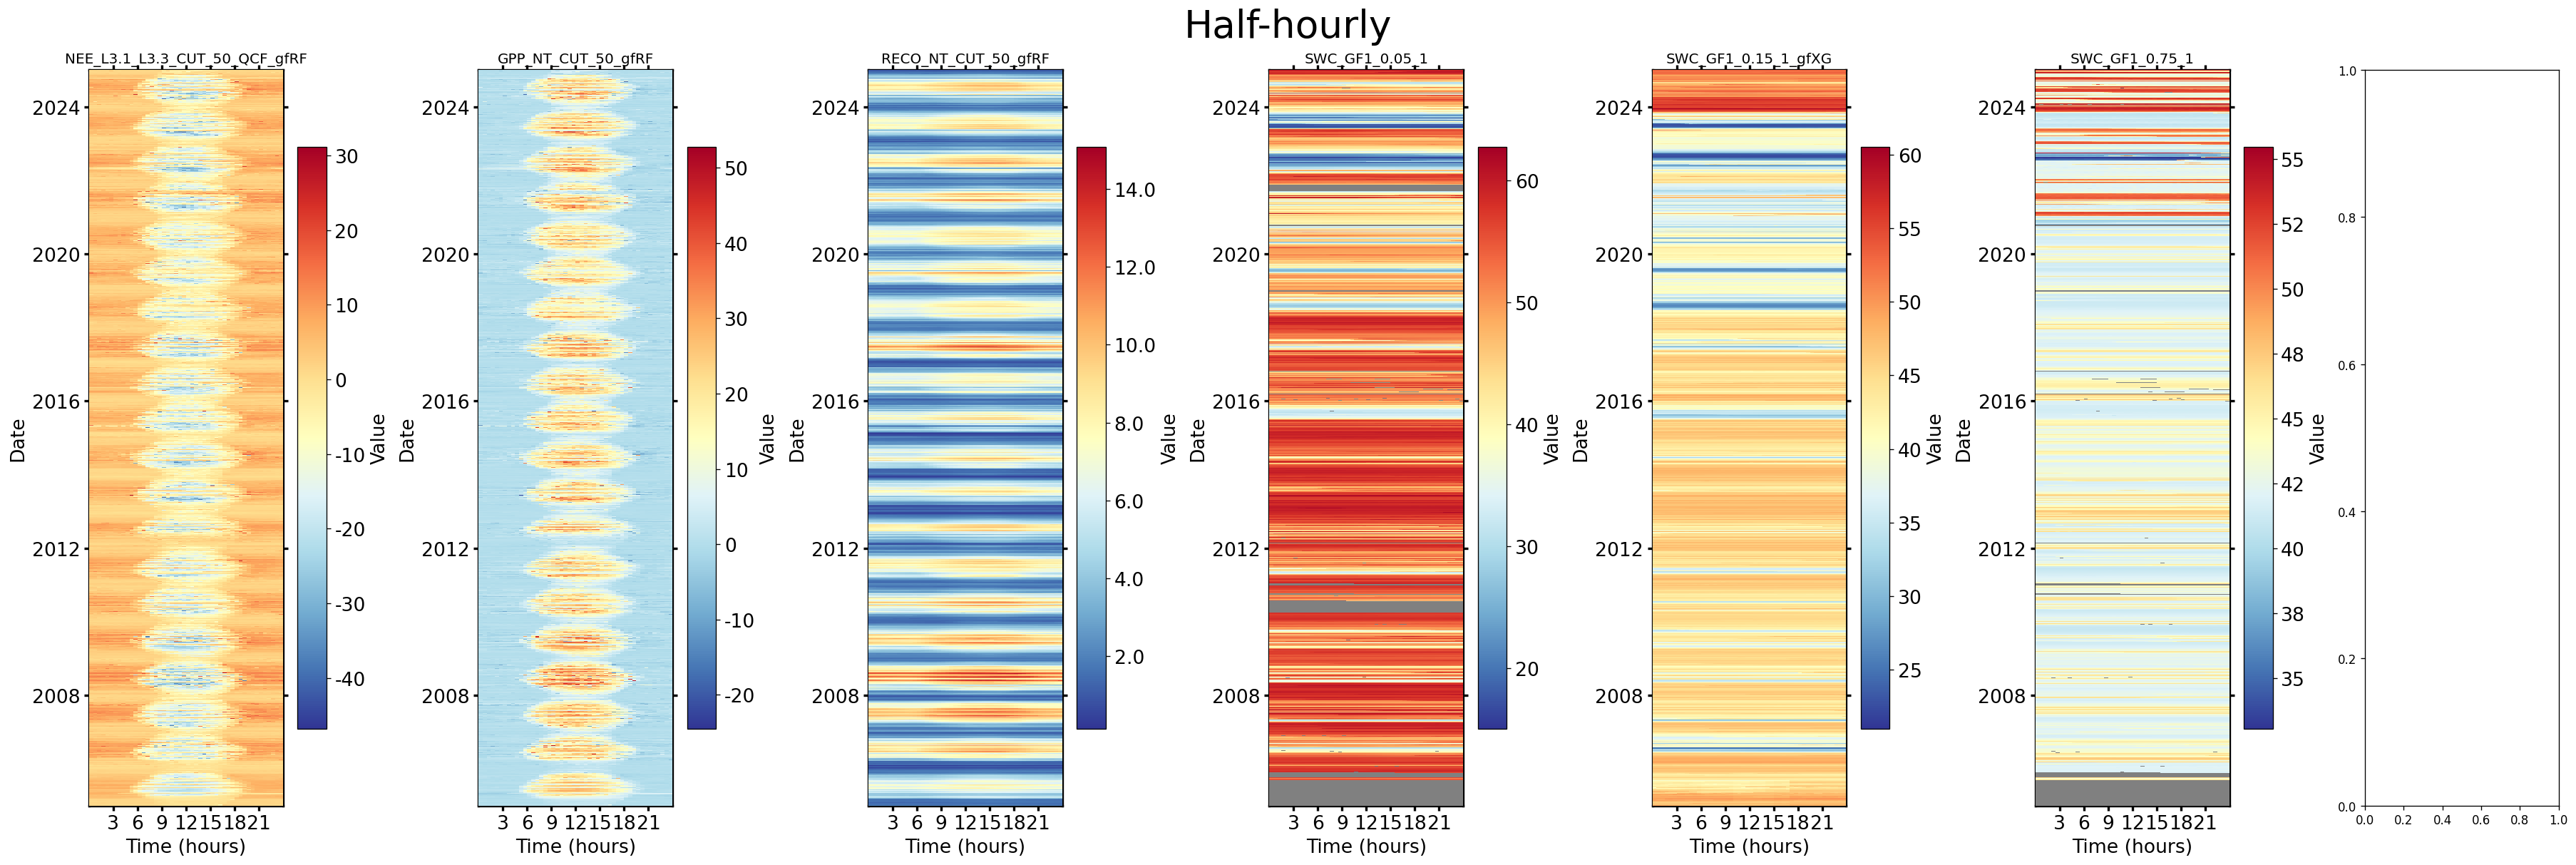

In [8]:
fig, axs = plt.subplots(ncols=7, figsize=(30, 10), dpi=120, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=32)
dv.heatmapdatetime(series=df['NEE_L3.1_L3.3_CUT_50_QCF_gfRF'], title="NEE_L3.1_L3.3_CUT_50_QCF_gfRF", ax=axs[0], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['GPP_NT_CUT_50_gfRF'], title="GPP_NT_CUT_50_gfRF", ax=axs[1], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['RECO_NT_CUT_50_gfRF'], title="RECO_NT_CUT_50_gfRF", ax=axs[2], cb_digits_after_comma=1).plot()
dv.heatmapdatetime(series=df['SWC_GF1_0.05_1'], title="SWC_GF1_0.05_1", ax=axs[3], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['SWC_GF1_0.15_1_gfXG'], title="SWC_GF1_0.15_1_gfXG", ax=axs[4], cb_digits_after_comma=0).plot()
dv.heatmapdatetime(series=df['SWC_GF1_0.75_1'], title="SWC_GF1_0.75_1", ax=axs[5], cb_digits_after_comma=0).plot()
# dv.heatmapdatetime(series=df['PREC_RAIN_TOT_GF1_0.5_1'], title="PREC_RAIN_TOT_GF1_0.5_1", ax=axs[6], cb_digits_after_comma=1).plot()

# Save to CSV file

In [9]:
_id = current_datetime_str_condensed()
df.to_csv(f"CH-CHA_2004-2024_SUBSET_{_id}.csv")

# End of notebook

In [10]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-06-19 12:16:44
